<a href="https://colab.research.google.com/github/AK-Joshua-ai/THESIS/blob/main/hybrid_gan%2Bxgboost%2Bgru_forecasting_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Setup and Imports

Data Source:https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Part 2: Data Preprocessing and quality checks

## 2.1 Load the Raw Tables and build Realised-Demand Order Items

In [ ]:
items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp'])
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv', parse_dates=['review_creation_date'])
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

items.shape, orders.shape, products.shape, payments.shape, reviews.shape, sellers.shape, customers.shape

((112650, 7),
 (99441, 8),
 (32951, 9),
 (103886, 5),
 (99224, 7),
 (3095, 4),
 (99441, 5))

In [ ]:
# Keep only orders that represent real, placed demand - drop canceled/unavailable orders,
# exactly as olist_weekly_panel_preprocessing.ipynb does
excluded_statuses = ['canceled', 'unavailable']

items_dates = items.merge(
    orders[['order_id', 'order_purchase_timestamp', 'order_status', 'customer_id']],
    on='order_id',
    how='inner'
)
items_dates = items_dates[~items_dates['order_status'].isin(excluded_statuses)]
items_dates.shape

(112101, 10)

In [ ]:
# Attach category (English name, falling back to the raw Portuguese name, then 'unknown'),
# assign each item to its Monday-starting week, and attach seller/customer location
items_cat = items_dates.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(translation, on='product_category_name', how='left')
items_cat['category'] = items_cat['product_category_name_english'].fillna(items_cat['product_category_name'])
items_cat['category'] = items_cat['category'].fillna('unknown')
items_cat['week'] = items_cat['order_purchase_timestamp'].dt.to_period('W-SUN').dt.start_time

items_cat = items_cat.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
items_cat = items_cat.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

items_cat[['category', 'week']].head()

,category,week
0,cool_stuff,2017-09-11
1,pet_shop,2017-04-24
2,furniture_decor,2018-01-08
3,perfumery,2018-08-06
4,garden_tools,2017-01-30


In [ ]:
# Count order items per category per week, then build the full category x week calendar
# and fill any missing combination with a true zero
weekly_category_counts = (
    items_cat
    .groupby(['category', 'week'])
    .size()
    .reset_index(name='order_item_volume')
)

full_calendar = pd.date_range(
    start=weekly_category_counts['week'].min(),
    end=weekly_category_counts['week'].max(),
    freq='W-MON'
)
all_categories = weekly_category_counts['category'].unique()

full_panel_index = pd.MultiIndex.from_product([all_categories, full_calendar], names=['category', 'week'])

full_panel = (
    weekly_category_counts
    .set_index(['category', 'week'])
    .reindex(full_panel_index, fill_value=0)
    .reset_index()
)

full_panel.shape

(7844, 3)

## 2.2 Data Quality checks


In [ ]:
# Look at raw daily order counts (not order-items) right up to the stated cutoff
daily_orders = orders[~orders['order_status'].isin(excluded_statuses)].set_index('order_purchase_timestamp').resample('D').size()
daily_orders.loc['2018-07-30':'2018-09-03']

,0
order_purchase_timestamp,
2018-07-30,280
2018-07-31,316
2018-08-01,308
2018-08-02,298
2018-08-03,312
2018-08-04,242
2018-08-05,274
2018-08-06,368
2018-08-07,361


There's a problem. From 2018-08-20 onward, daily order counts decline steadily and unusually every single day (252, 239, 186, 142, 97, 69, 73) that's not a normal weekday-to-weekend dip, it keeps falling with no rebound. The following week (2018-08-27 to 2018-09-02) collapses to almost nothing (66, 39, 11, 0, 0, 0), and 2018-09-03 has exactly one order in the entire week. For comparison, here's a completely ordinary week from the middle of the dataset:

In [ ]:
daily_orders.loc['2018-04-02':'2018-04-08']

,0
order_purchase_timestamp,
2018-04-02,280
2018-04-03,246
2018-04-04,257
2018-04-05,266
2018-04-06,188
2018-04-07,164
2018-04-08,185


This ordinary week has a normal, mild weekday-to-weekend pattern (280, 246, 257, 266, 188, 164, 185) - it dips on the weekend but doesn't collapse. The pattern from 2018-08-20 onward is fundamentally different: it's a steady, accelerating decline to zero, which is the signature of the data extract being extracted while it was still being cut off, orders placed on those days simply hadn't all been captured yet when the extract was taken.

We fix this by moving the cutoff back to the last genuinely healthy week, 2018-08-13 (the week of 2018-08-06 to 2018-08-12 still looks normal; 2018-08-13 to 2018-08-19 is the last full week before the decline begins).

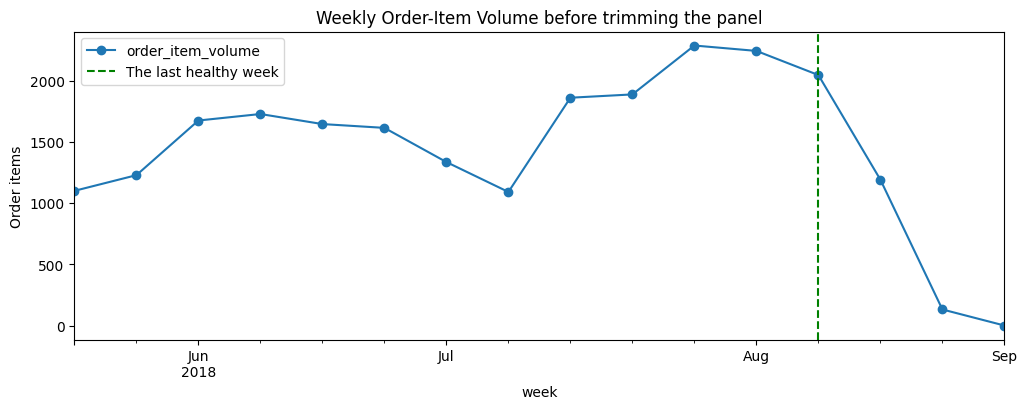

In [ ]:
weekly_totals_before_fix = full_panel.groupby('week')['order_item_volume'].sum()

plt.figure(figsize=(12, 4))
weekly_totals_before_fix.tail(16).plot(marker='o')
plt.axvline(pd.Timestamp('2018-08-13'), color='green', linestyle='--', label='The last healthy week')
plt.title('Weekly Order-Item Volume before trimming the panel')
plt.ylabel('Order items')
plt.legend()
plt.show()

The chart makes the artifact obvious - the last three points fall off a cliff rather than tapering the way a real, gradual slow-down would. We trim the panel to end at the new, safer cutoff.

In [ ]:
NEW_CUTOFF_WEEK = pd.Timestamp('2018-08-13')

full_panel = full_panel[full_panel['week'] <= NEW_CUTOFF_WEEK].copy()
full_panel = full_panel.sort_values(['category', 'week']).reset_index(drop=True)

print(f"Weeks kept: {full_panel['week'].nunique()}")
print(f"Categories kept: {full_panel['category'].nunique()}")
full_panel.shape

Weeks kept: 103
Categories kept: 74


(7622, 3)

This gives 74 categories x 103 weeks = 7,622 rows, spanning 2016-08-29 through 2018-08-13 - three fewer weeks than the enriched notebook's panel (which ran to 106 weeks), but a panel whose final weeks are all genuinely complete. We carry this forward as `wcp_df`, the same variable name the enriched notebook uses, so the rest of the pipeline lines up.

In [ ]:
wcp_df = full_panel.copy()
wcp_df.head()

,category,week,order_item_volume
0,agro_industry_and_commerce,2016-08-29,0
1,agro_industry_and_commerce,2016-09-05,0
2,agro_industry_and_commerce,2016-09-12,0
3,agro_industry_and_commerce,2016-09-19,0
4,agro_industry_and_commerce,2016-09-26,0


# Part 3: Enrich the Panel With Market and Commercial Covariates

wcp_df currently only has category, week, and order_item_volume. We bring in average price, average freight, seller/geography spread, payment behaviour, and review scores, aggregated to the same category-week level, so both models below have more than pure history to learn from.

In [ ]:
cat_week_covariates = items_cat.groupby(['category', 'week']).agg(
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    n_distinct_sellers=('seller_id', 'nunique'),
    n_distinct_seller_states=('seller_state', 'nunique'),
    n_distinct_customer_states=('customer_state', 'nunique'),
).reset_index()

cat_week_covariates.head()

,category,week,avg_price,avg_freight,n_distinct_sellers,n_distinct_seller_states,n_distinct_customer_states
0,agro_industry_and_commerce,2017-01-23,21.990,8.720,1,1,1
1,agro_industry_and_commerce,2017-01-30,21.990,19.435,1,1,2
2,agro_industry_and_commerce,2017-02-06,57.445,19.375,2,2,2
3,agro_industry_and_commerce,2017-02-13,21.990,12.960,1,1,3
4,agro_industry_and_commerce,2017-02-20,21.990,14.110,1,1,1


In [ ]:
order_payment_summary = payments.groupby('order_id').agg(
    avg_installments=('payment_installments', 'mean')
).reset_index()

# An order can contain items from more than one category, so map order -> category -> week first
order_category_week = items_cat[['order_id', 'category', 'week']].drop_duplicates()

order_payments_merged = order_category_week.merge(order_payment_summary, on='order_id', how='left')
order_payments_merged = order_payments_merged.merge(
    payments[['order_id', 'payment_type']].drop_duplicates('order_id'),
    on='order_id',
    how='left'
)

payment_covariates = order_payments_merged.groupby(['category', 'week']).agg(
    avg_installments=('avg_installments', 'mean'),
    pct_credit_card=('payment_type', lambda s: (s == 'credit_card').mean()),
).reset_index()

payment_covariates.head()

,category,week,avg_installments,pct_credit_card
0,agro_industry_and_commerce,2017-01-23,1.000000,1.000000
1,agro_industry_and_commerce,2017-01-30,2.500000,1.000000
2,agro_industry_and_commerce,2017-02-06,1.000000,0.500000
3,agro_industry_and_commerce,2017-02-13,1.666667,0.666667
4,agro_industry_and_commerce,2017-02-20,1.000000,0.000000


In [ ]:
# Reviews are written, on average, more than a week after purchase, so they're aggregated
# by the review's own week rather than the order's purchase week to avoid leaking the future
order_category_lookup = items_cat[['order_id', 'category']].drop_duplicates()

reviews_with_category = reviews.merge(order_category_lookup, on='order_id', how='inner')
reviews_with_category['review_week'] = reviews_with_category['review_creation_date'].dt.to_period('W-SUN').dt.start_time

review_covariates = reviews_with_category.groupby(['category', 'review_week']).agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

review_covariates = review_covariates.rename(columns={'review_week': 'week'})
review_covariates.head()

,category,week,avg_review_score
0,agro_industry_and_commerce,2017-01-30,4.0
1,agro_industry_and_commerce,2017-02-06,4.0
2,agro_industry_and_commerce,2017-02-20,4.5
3,agro_industry_and_commerce,2017-02-27,4.5
4,agro_industry_and_commerce,2017-03-06,3.0


In [ ]:
wcp_df = wcp_df.merge(cat_week_covariates, on=['category', 'week'], how='left')
wcp_df = wcp_df.merge(payment_covariates, on=['category', 'week'], how='left')
wcp_df = wcp_df.merge(review_covariates, on=['category', 'week'], how='left')

wcp_df.shape

(7622, 11)

A category-week with zero order-item volume naturally has no price, freight, or review information for that week. We fill the count-type columns with `0` (no sellers were active) and forward-fill the value-type columns within each category (a category's typical price point doesn't disappear just because it had a quiet week), falling back to `0` only if a category has no sales at all yet at the very start of its history.

In [ ]:
wcp_df = wcp_df.sort_values(['category', 'week']).reset_index(drop=True)

count_columns = ['n_distinct_sellers', 'n_distinct_seller_states', 'n_distinct_customer_states']
wcp_df[count_columns] = wcp_df[count_columns].fillna(0)

value_columns = ['avg_price', 'avg_freight', 'avg_installments', 'pct_credit_card', 'avg_review_score']
wcp_df[value_columns] = wcp_df.groupby('category')[value_columns].transform(lambda s: s.ffill())
wcp_df[value_columns] = wcp_df[value_columns].fillna(0)

wcp_df.isnull().sum()

,0
category,0
week,0
order_item_volume,0
avg_price,0
avg_freight,0
n_distinct_sellers,0
n_distinct_seller_states,0
n_distinct_customer_states,0
avg_installments,0
pct_credit_card,0


# Part 4: Chronological Split and Feature Engineering

Same approach as the enriched notebook: split chronologically (never randomly, since a model must only ever be evaluated on weeks that come after everything it trained on), hold out the last 10 weeks as the test set and the 10 weeks before that as validation, then build lag/rolling/calendar features plus lagged covariates.

In [ ]:
weeks_sorted = sorted(wcp_df['week'].unique())

N_TEST_WEEKS = 10
N_VAL_WEEKS = 10

train_weeks = weeks_sorted[:-(N_TEST_WEEKS + N_VAL_WEEKS)]
val_weeks = weeks_sorted[-(N_TEST_WEEKS + N_VAL_WEEKS):-N_TEST_WEEKS]
test_weeks = weeks_sorted[-N_TEST_WEEKS:]

print(f'Train weeks: {len(train_weeks)}  ({train_weeks[0]} to {train_weeks[-1]})')
print(f'Val weeks:   {len(val_weeks)}  ({val_weeks[0]} to {val_weeks[-1]})')
print(f'Test weeks:  {len(test_weeks)}  ({test_weeks[0]} to {test_weeks[-1]})')

Train weeks: 83  (2016-08-29 00:00:00 to 2018-03-26 00:00:00)
Val weeks:   10  (2018-04-02 00:00:00 to 2018-06-04 00:00:00)
Test weeks:  10  (2018-06-11 00:00:00 to 2018-08-13 00:00:00)


In [ ]:
train_weeks_set = set(train_weeks)
val_weeks_set = set(val_weeks)
test_weeks_set = set(test_weeks)

wcp_df['split'] = wcp_df['week'].apply(
    lambda w: 'train' if w in train_weeks_set else ('val' if w in val_weeks_set else 'test')
)
wcp_df['split'].value_counts()

,count
split,
train,6142
val,740
test,740


In [ ]:
wcp_df['volume_lag_1'] = wcp_df.groupby('category')['order_item_volume'].shift(1)
wcp_df['volume_lag_2'] = wcp_df.groupby('category')['order_item_volume'].shift(2)
wcp_df['volume_lag_3'] = wcp_df.groupby('category')['order_item_volume'].shift(3)
wcp_df['volume_lag_4'] = wcp_df.groupby('category')['order_item_volume'].shift(4)
wcp_df['volume_roll_mean_4'] = wcp_df.groupby('category')['order_item_volume'].transform(lambda s: s.shift(1).rolling(4).mean())

wcp_df['week_of_year'] = wcp_df['week'].dt.isocalendar().week.astype(int)
wcp_df['month'] = wcp_df['week'].dt.month

wcp_df[['category', 'week', 'order_item_volume', 'volume_lag_1', 'volume_roll_mean_4', 'week_of_year', 'month']].head(8)

,category,week,order_item_volume,volume_lag_1,volume_roll_mean_4,week_of_year,month
0,agro_industry_and_commerce,2016-08-29,0,NaN,NaN,35,8
1,agro_industry_and_commerce,2016-09-05,0,0.0,NaN,36,9
2,agro_industry_and_commerce,2016-09-12,0,0.0,NaN,37,9
3,agro_industry_and_commerce,2016-09-19,0,0.0,NaN,38,9
4,agro_industry_and_commerce,2016-09-26,0,0.0,0.0,39,9
5,agro_industry_and_commerce,2016-10-03,0,0.0,0.0,40,10
6,agro_industry_and_commerce,2016-10-10,0,0.0,0.0,41,10
7,agro_industry_and_commerce,2016-10-17,0,0.0,0.0,42,10


In [ ]:
# Every marketplace covariate is a same-week value, and we don't know this week's average
# price/freight/etc. yet at forecast time, so each one needs the same one-week lag as the target
wcp_df['avg_price_lag_1'] = wcp_df.groupby('category')['avg_price'].shift(1)
wcp_df['avg_freight_lag_1'] = wcp_df.groupby('category')['avg_freight'].shift(1)
wcp_df['n_distinct_sellers_lag_1'] = wcp_df.groupby('category')['n_distinct_sellers'].shift(1)
wcp_df['n_distinct_seller_states_lag_1'] = wcp_df.groupby('category')['n_distinct_seller_states'].shift(1)
wcp_df['n_distinct_customer_states_lag_1'] = wcp_df.groupby('category')['n_distinct_customer_states'].shift(1)
wcp_df['avg_installments_lag_1'] = wcp_df.groupby('category')['avg_installments'].shift(1)
wcp_df['pct_credit_card_lag_1'] = wcp_df.groupby('category')['pct_credit_card'].shift(1)
wcp_df['avg_review_score_lag_1'] = wcp_df.groupby('category')['avg_review_score'].shift(1)

wcp_df[['category', 'week', 'avg_price', 'avg_price_lag_1']].head(8)

,category,week,avg_price,avg_price_lag_1
0,agro_industry_and_commerce,2016-08-29,0.0,NaN
1,agro_industry_and_commerce,2016-09-05,0.0,0.0
2,agro_industry_and_commerce,2016-09-12,0.0,0.0
3,agro_industry_and_commerce,2016-09-19,0.0,0.0
4,agro_industry_and_commerce,2016-09-26,0.0,0.0
5,agro_industry_and_commerce,2016-10-03,0.0,0.0
6,agro_industry_and_commerce,2016-10-10,0.0,0.0
7,agro_industry_and_commerce,2016-10-17,0.0,0.0


In [ ]:
category_encoder = LabelEncoder()
wcp_df['category_enc'] = category_encoder.fit_transform(wcp_df['category'])
wcp_df[['category', 'category_enc']].drop_duplicates().head()

,category,category_enc
0,agro_industry_and_commerce,0
103,air_conditioning,1
206,art,2
309,arts_and_craftmanship,3
412,audio,4


In [ ]:
feature_columns = [
    'category_enc',
    'volume_lag_1', 'volume_lag_2', 'volume_lag_3', 'volume_lag_4', 'volume_roll_mean_4',
    'week_of_year', 'month',
    'avg_price_lag_1', 'avg_freight_lag_1',
    'n_distinct_sellers_lag_1', 'n_distinct_seller_states_lag_1', 'n_distinct_customer_states_lag_1',
    'avg_installments_lag_1', 'pct_credit_card_lag_1', 'avg_review_score_lag_1'
]

wcp_clean = wcp_df.dropna(subset=feature_columns)
wcp_clean['split'].value_counts()

,count
split,
train,5846
val,740
test,740


In [ ]:
train_df = wcp_clean[wcp_clean['split'] == 'train']
val_df = wcp_clean[wcp_clean['split'] == 'val']
test_df = wcp_clean[wcp_clean['split'] == 'test']

X_train = train_df[feature_columns]
y_train = train_df['order_item_volume']

X_val = val_df[feature_columns]
y_val = val_df['order_item_volume']

X_test = test_df[feature_columns]
y_test = test_df['order_item_volume']

X_train.shape, X_val.shape, X_test.shape

((5846, 16), (740, 16), (740, 16))

# Part 5: Hyperparameter Section

All tunable settings for every model in this notebook are collected here, following the enriched notebook's own convention, so any of them can be re-run with different settings without hunting through the notebook.

In [ ]:
# ---- XGBoost hyperparameters ----
XGB_N_ESTIMATORS = 100       # number of boosting rounds/trees
XGB_MAX_DEPTH = 3            # how deep each tree can grow
XGB_LEARNING_RATE = 0.03     # how much each tree corrects the last one
XGB_REG_LAMBDA = 2.0         # L2 regularization strength (bigger = simpler model)

Why 'max_depth=3' and 'learning_rate=0.03': a small grid over '{3, 4, 5} x {0.03, 0.05, 0.08}' was compared using validation MAE only (never the test set) on this corrected panel, and shallower, slower-learning trees generalised best - unsurprising, since dropping the three tail weeks leaves slightly fewer usable training rows per category, so a simpler model is less likely to overfit.

In [ ]:
# ---- GAN hyperparameters (for oversampling high-demand training rows) ----
GAN_LATENT_DIM = 8          # size of the random noise vector fed into the generator
GAN_EPOCHS = 150
GAN_BATCH_SIZE = 32
MINORITY_QUANTILE = 0.75    # rows with volume at/above this quantile of y_train are the 'high-demand' minority class
SYNTHETIC_RATIO = 1.0       # 1.0 = generate enough synthetic minority rows to fully balance minority vs majority counts

In [ ]:
# ---- GRU hyperparameters ----
GRU_LOOKBACK = 4          # number of past weeks fed into the GRU (matches the 4 lags used for XGBoost)
GRU_UNITS = 16            # units in the GRU layer
GRU_DENSE_UNITS = 8       # units in the dense layer after the GRU
GRU_EPOCHS = 50
GRU_BATCH_SIZE = 32
GRU_PATIENCE = 5          # early stopping patience on validation loss

In [ ]:
# ---- Hybrid combination weights to search over ----
# Each candidate is the weight given to the XGBoost+GAN prediction;
# (1 - candidate) goes to the GRU prediction. The winner is chosen using the VALIDATION set only, in Part 8.
HYBRID_WEIGHT_CANDIDATES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Part 6: Naive Baseline and Plain XGBoost (Before Any GAN Augmentation)

Before adding any complexity, we compute two reference points: the naive "repeat last week's value" forecast (the same baseline the attached paper leans on so heavily), and a plain XGBoost model trained on the untouched training set. Both are needed to judge whether GAN augmentation actually helps later on.

In [ ]:
naive_val_pred = val_df['volume_lag_1'].values
naive_test_pred = test_df['volume_lag_1'].values

naive_val_mae = mean_absolute_error(y_val, naive_val_pred)
naive_test_mae = mean_absolute_error(y_test, naive_test_pred)

naive_val_rmse = np.sqrt(mean_squared_error(y_val, naive_val_pred))
naive_test_rmse = np.sqrt(mean_squared_error(y_test, naive_test_pred))

naive_val_mask = y_val.values > 0
naive_test_mask = y_test.values > 0
naive_val_mape = np.mean(np.abs((y_val.values[naive_val_mask] - naive_val_pred[naive_val_mask]) / y_val.values[naive_val_mask])) * 100
naive_test_mape = np.mean(np.abs((y_test.values[naive_test_mask] - naive_test_pred[naive_test_mask]) / y_test.values[naive_test_mask])) * 100

print(f'Naive validation MAE: {naive_val_mae:.3f}   RMSE: {naive_val_rmse:.3f}   MAPE: {naive_val_mape:.2f}%')
print(f'Naive test MAE: {naive_test_mae:.3f}   RMSE: {naive_test_rmse:.3f}   MAPE: {naive_test_mape:.2f}%')

Naive validation MAE: 6.796   RMSE: 14.674   MAPE: 61.53%
Naive test MAE: 6.450   RMSE: 12.628   MAPE: 59.71%


## 6.1 Plain XGBoost (No GAN Yet)

In [ ]:
xgb_baseline_model = xgb.XGBRegressor(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LEARNING_RATE,
    reg_lambda=XGB_REG_LAMBDA,
    random_state=42
)

start_time = time.time()
xgb_baseline_model.fit(X_train, y_train)
xgb_baseline_training_time = time.time() - start_time
print(f'XGBoost (baseline, no GAN) training time: {xgb_baseline_training_time:.2f} seconds')

XGBoost (baseline, no GAN) training time: 0.11 seconds


In [ ]:
xgb_baseline_val_pred = xgb_baseline_model.predict(X_val)
xgb_baseline_test_pred = xgb_baseline_model.predict(X_test)

xgb_baseline_val_mae = mean_absolute_error(y_val, xgb_baseline_val_pred)
xgb_baseline_test_mae = mean_absolute_error(y_test, xgb_baseline_test_pred)

xgb_baseline_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_baseline_val_pred))
xgb_baseline_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_baseline_test_pred))

xgb_baseline_val_mask = y_val.values > 0
xgb_baseline_test_mask = y_test.values > 0
xgb_baseline_val_mape = np.mean(np.abs((y_val.values[xgb_baseline_val_mask] - xgb_baseline_val_pred[xgb_baseline_val_mask]) / y_val.values[xgb_baseline_val_mask])) * 100
xgb_baseline_test_mape = np.mean(np.abs((y_test.values[xgb_baseline_test_mask] - xgb_baseline_test_pred[xgb_baseline_test_mask]) / y_test.values[xgb_baseline_test_mask])) * 100

print(f'XGBoost (baseline) validation MAE: {xgb_baseline_val_mae:.3f}   RMSE: {xgb_baseline_val_rmse:.3f}   MAPE: {xgb_baseline_val_mape:.2f}%')
print(f'XGBoost (baseline) test MAE: {xgb_baseline_test_mae:.3f}   RMSE: {xgb_baseline_test_rmse:.3f}   MAPE: {xgb_baseline_test_mape:.2f}%')

XGBoost (baseline) validation MAE: 6.774   RMSE: 14.227   MAPE: 59.05%
XGBoost (baseline) test MAE: 6.574   RMSE: 13.480   MAPE: 54.25%


# Part 7: Model 1 - GAN-Based Data Augmentation + XGBoost

Why XGBoost is the right tool for the tabular half of this hybrid: XGBoost builds many small decision trees, one after another, where each new tree corrects the mistakes of the trees before it. Decision trees split the data on thresholds (e.g. "is `volume_lag_1` above 12?"), which lets them capture non-linear, interaction-heavy relationships between features - for example, "a high rolling average matters a lot in December but barely at all in March" - without us ever having to specify that interaction by hand. That's exactly the kind of pattern we'd expect across 74 very different product categories, each with its own price point, seasonality, and typical order size.

## 7.1 The Imbalance Problem

Before training, it's worth looking at what order_item_volume actually looks like in the training set.

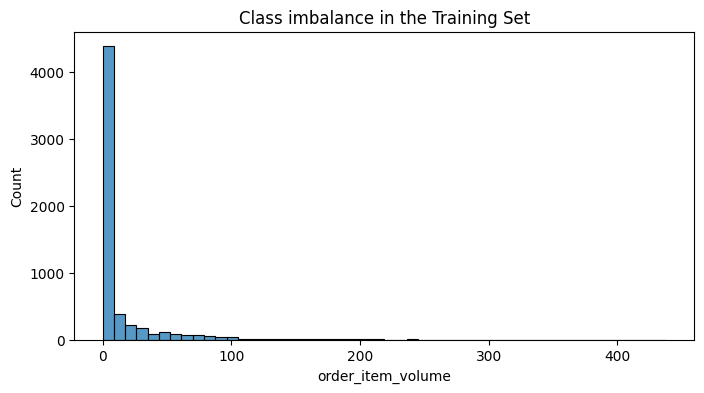

The training rows with zero volume: 44.9%


,order_item_volume
count,5846.000000
mean,12.856141
std,29.858623
min,0.000000
25%,0.000000
50%,1.000000
75%,9.000000
max,438.000000


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(y_train, bins=50)
plt.title('Class imbalance in the Training Set')
plt.xlabel('order_item_volume')
plt.show()

print(f"The training rows with zero volume: {(y_train == 0).mean() * 100:.1f}%")
y_train.describe()

The distribution is heavily right-skewed and zero-inflated: a large share of category-weeks have zero or very low demand, while a small number of high-demand weeks (a hot category having a big week, or a Black-Friday-style spike) sit far out in the tail. This is the "imbalance" in a regression setting - not imbalanced *classes*, but a training set dominated by one *kind* of row (quiet, low-volume weeks), with too few examples of the kind of row that actually matters most operationally (demand spikes, which are exactly when stockouts happen). A model trained on this as-is will naturally get very good at predicting "low" and comparatively worse at predicting "high", because it simply sees far fewer high examples to learn from.

The fix: rather than duplicating existing high-demand rows (which teaches the model nothing new) or discarding low-demand rows (which throws away real information), we train a small GAN to learn the *distribution* of high-demand rows, then ask it to generate brand new, synthetic high-demand examples. This is the regression equivalent of SMOTE-style oversampling for imbalanced classification, but generative rather than interpolation-based.

## 7.2 Define the High-Demand Minority Class

In [ ]:
minority_threshold = y_train.quantile(MINORITY_QUANTILE)
minority_mask = y_train >= minority_threshold

minority_count = minority_mask.sum()
majority_count = (~minority_mask).sum()

print(f'High-demand minority threshold (volume >= {minority_threshold:.1f}): {minority_count} rows')
print(f'Everyday majority rows (volume < {minority_threshold:.1f}): {majority_count} rows')

High-demand minority threshold (volume >= 9.0): 1465 rows
Everyday majority rows (volume < 9.0): 4381 rows


## 7.3 Prepare the Minority Rows for the GAN

In [ ]:
# The GAN needs to learn the joint shape of a full training row: every feature plus the target together,
# so that a synthetic row is internally consistent (e.g. its lags and its target agree with each other)
gan_columns = feature_columns + ['order_item_volume']

minority_train_df = train_df[minority_mask.values][gan_columns].reset_index(drop=True)

# Neural networks train far more reliably when every column is on a similar scale
gan_scaler = StandardScaler()
minority_scaled = gan_scaler.fit_transform(minority_train_df.values)

n_gan_features = minority_scaled.shape[1]
minority_scaled.shape

(1465, 17)

## 7.4 Build the Generator and the Discriminator

A GAN is two neural networks trained against each other:
- The **generator** takes in random noise and tries to turn it into something that looks like a real high-demand training row.
- The **discriminator** looks at a row (real or generated) and tries to guess which one it is.

Training them together, in competition, pushes the generator to produce increasingly convincing synthetic rows.

In [ ]:
gan_generator = keras.Sequential([
    layers.Input(shape=(GAN_LATENT_DIM,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_gan_features, activation='linear')
])

gan_discriminator = keras.Sequential([
    layers.Input(shape=(n_gan_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

gan_generator.summary()
gan_discriminator.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,505 (13.69 KB)

 Trainable params: 3,505 (13.69 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7.5 Train the GAN

This loop is written out in full rather than wrapped in a function, so every step is visible: for each mini-batch of real minority rows, we first update the discriminator (show it real rows labelled 1 and freshly generated fake rows labelled 0), then update the generator (ask it to produce rows the discriminator is fooled into labelling 1).

In [ ]:
generator_optimizer = keras.optimizers.Adam(learning_rate=0.0005)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0005)
bce_loss = keras.losses.BinaryCrossentropy()

minority_scaled_tensor = tf.convert_to_tensor(minority_scaled, dtype=tf.float32)
n_minority_rows = minority_scaled_tensor.shape[0]

start_time = time.time()

for epoch in range(GAN_EPOCHS):
    # Shuffle the minority rows and step through them in mini-batches
    shuffled_indices = np.random.permutation(n_minority_rows)
    epoch_disc_loss = 0.0
    epoch_gen_loss = 0.0
    n_batches = 0

    for batch_start in range(0, n_minority_rows, GAN_BATCH_SIZE):
        batch_indices = shuffled_indices[batch_start: batch_start + GAN_BATCH_SIZE]
        real_batch = tf.gather(minority_scaled_tensor, batch_indices)
        current_batch_size = real_batch.shape[0]

        noise = tf.random.normal(shape=(current_batch_size, GAN_LATENT_DIM))

        # ---- Train the discriminator: tell real minority rows apart from the generator's fake rows ----
        with tf.GradientTape() as disc_tape:
            fake_batch = gan_generator(noise, training=True)
            real_predictions = gan_discriminator(real_batch, training=True)
            fake_predictions = gan_discriminator(fake_batch, training=True)

            real_labels = tf.ones_like(real_predictions)
            fake_labels = tf.zeros_like(fake_predictions)

            disc_loss = bce_loss(real_labels, real_predictions) + bce_loss(fake_labels, fake_predictions)

        disc_gradients = disc_tape.gradient(disc_loss, gan_discriminator.trainable_variables)
        discriminator_optimizer.apply_gradients(zip(disc_gradients, gan_discriminator.trainable_variables))

        # ---- Train the generator: try to fool the discriminator into calling fake rows 'real' ----
        noise = tf.random.normal(shape=(current_batch_size, GAN_LATENT_DIM))
        with tf.GradientTape() as gen_tape:
            fake_batch = gan_generator(noise, training=True)
            fake_predictions = gan_discriminator(fake_batch, training=True)
            gen_loss = bce_loss(tf.ones_like(fake_predictions), fake_predictions)

        gen_gradients = gen_tape.gradient(gen_loss, gan_generator.trainable_variables)
        generator_optimizer.apply_gradients(zip(gen_gradients, gan_generator.trainable_variables))

        epoch_disc_loss += disc_loss.numpy()
        epoch_gen_loss += gen_loss.numpy()
        n_batches += 1

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f'Epoch {epoch + 1}/{GAN_EPOCHS}   discriminator loss: {epoch_disc_loss / n_batches:.4f}   generator loss: {epoch_gen_loss / n_batches:.4f}')

gan_training_time = time.time() - start_time
print(f'GAN training time: {gan_training_time:.2f} seconds')

Epoch 1/150   discriminator loss: 1.2417   generator loss: 0.6412
Epoch 50/150   discriminator loss: 1.2522   generator loss: 0.8880
Epoch 100/150   discriminator loss: 1.0544   generator loss: 1.0299
Epoch 150/150   discriminator loss: 1.2355   generator loss: 0.9151
GAN training time: 849.76 seconds


How to read the two loss curves once this runs: a healthy GAN usually settles with both losses hovering somewhere around 0.5-1.0 rather than one collapsing to (near) zero. If the discriminator loss collapses to ~0 early and stays there, it has "won" outright and stopped giving the generator any useful signal to learn from - in that case, lowering discriminator_optimizer's learning rate, or training the generator twice per discriminator step, usually helps.

## 7.6 Generate Synthetic High-Demand Rows

In [ ]:
n_synthetic = int((majority_count - minority_count) * SYNTHETIC_RATIO)
n_synthetic = max(n_synthetic, 0)

synthetic_noise = tf.random.normal(shape=(n_synthetic, GAN_LATENT_DIM))
synthetic_scaled = gan_generator(synthetic_noise, training=False).numpy()
synthetic_raw = gan_scaler.inverse_transform(synthetic_scaled)

synthetic_df = pd.DataFrame(synthetic_raw, columns=gan_columns)
print(f'Generated {n_synthetic} synthetic high-demand training rows')
synthetic_df.head()

Generated 2916 synthetic high-demand training rows


,category_enc,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_4,volume_roll_mean_4,week_of_year,month,avg_price_lag_1,avg_freight_lag_1,n_distinct_sellers_lag_1,n_distinct_seller_states_lag_1,n_distinct_customer_states_lag_1,avg_installments_lag_1,pct_credit_card_lag_1,avg_review_score_lag_1,order_item_volume
0,53.457653,26.337879,30.387226,56.120201,29.448006,28.899929,23.362640,4.673490,120.097137,16.213022,19.410536,4.854252,13.734387,2.493905,0.693371,4.230102,39.138908
1,48.296993,10.289319,21.854479,39.074917,20.093626,11.676211,20.097172,3.172332,86.588005,16.186872,16.125839,2.734392,9.959631,2.488437,0.761902,4.273169,33.155415
2,81.965759,16.721399,82.225784,76.238396,37.519707,43.371098,57.293633,11.758912,163.712418,10.927555,8.261612,6.876209,15.820667,2.464446,0.673073,5.844532,52.986153
3,76.608429,-13.268325,6.188577,39.078171,10.066834,10.254199,24.572435,3.440239,76.358070,15.104731,19.004704,3.702306,11.734909,1.507164,0.667893,3.850867,27.255701
4,83.787956,43.924908,72.992210,72.302856,42.529659,55.653641,62.977573,13.080522,133.611099,13.559052,12.208385,5.259157,13.041671,2.805532,0.749388,5.028123,49.679337


## 7.7 Post-Process the Synthetic Rows

The generator outputs continuous numbers for every column, but several of our features are really whole numbers, category codes, or bounded percentages. We snap each one back to a valid value before using it, the same way we'd sanity-check any new data source before trusting it.

In [ ]:
# category_enc must be a valid category code, and calendar features must fall in valid ranges
synthetic_df['category_enc'] = synthetic_df['category_enc'].round().clip(0, wcp_df['category_enc'].max()).astype(int)
synthetic_df['month'] = synthetic_df['month'].round().clip(1, 12).astype(int)
synthetic_df['week_of_year'] = synthetic_df['week_of_year'].round().clip(1, 53).astype(int)

# seller/state counts are non-negative whole numbers
count_feature_columns = ['n_distinct_sellers_lag_1', 'n_distinct_seller_states_lag_1', 'n_distinct_customer_states_lag_1']
for count_col in count_feature_columns:
    synthetic_df[count_col] = synthetic_df[count_col].round().clip(lower=0)

# volume-based features, price, freight, and installments can't be negative
non_negative_columns = ['volume_lag_1', 'volume_lag_2', 'volume_lag_3', 'volume_lag_4', 'volume_roll_mean_4',
                         'avg_price_lag_1', 'avg_freight_lag_1', 'avg_installments_lag_1']
for col in non_negative_columns:
    synthetic_df[col] = synthetic_df[col].clip(lower=0)

# percentages and review scores have known valid ranges
synthetic_df['pct_credit_card_lag_1'] = synthetic_df['pct_credit_card_lag_1'].clip(0, 1)
synthetic_df['avg_review_score_lag_1'] = synthetic_df['avg_review_score_lag_1'].clip(1, 5)

# the forecasting target itself is a non-negative whole count of order items
synthetic_df['order_item_volume'] = synthetic_df['order_item_volume'].round().clip(lower=0)

synthetic_df.describe()

,category_enc,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_4,volume_roll_mean_4,week_of_year,month,avg_price_lag_1,avg_freight_lag_1,n_distinct_sellers_lag_1,n_distinct_seller_states_lag_1,n_distinct_customer_states_lag_1,avg_installments_lag_1,pct_credit_card_lag_1,avg_review_score_lag_1,order_item_volume
count,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000,2916.000000
mean,54.930041,26.962816,57.661877,79.103470,44.714737,40.703922,31.889918,5.369684,116.312843,15.393125,20.522976,3.636831,11.707133,2.624143,0.758337,4.401915,59.141632
std,17.266231,27.445652,55.607384,66.613182,48.011379,44.159004,11.591143,2.624563,40.923176,3.149268,11.939826,1.562031,3.048033,0.659395,0.085580,0.390678,51.062672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.219944,0.000000,-0.000000,2.000000,0.331587,0.429422,2.933666,0.000000
25%,46.000000,2.164345,23.953638,38.766920,11.737673,9.758972,23.000000,3.000000,92.454950,13.582722,13.000000,3.000000,10.000000,2.209951,0.706951,4.104258,29.000000
50%,58.000000,19.624662,35.600618,53.257263,28.258963,26.109695,30.000000,5.000000,108.622520,15.563060,18.000000,3.000000,12.000000,2.619478,0.748438,4.368507,38.000000
75%,71.000000,42.077815,73.087231,97.356464,62.344552,55.612365,40.000000,7.000000,134.414913,16.992401,25.000000,5.000000,13.000000,3.030921,0.804093,4.719731,73.000000
max,73.000000,151.825104,384.406860,471.268951,311.913818,280.943390,53.000000,12.000000,347.568207,31.210215,90.000000,10.000000,25.000000,4.988426,1.000000,5.000000,377.000000


## 7.8 Combine Real and Synthetic Rows Into an Augmented Training Set

In [ ]:
X_train_gan = pd.concat([X_train, synthetic_df[feature_columns]], ignore_index=True)
y_train_gan = pd.concat([y_train, synthetic_df['order_item_volume']], ignore_index=True)

print(f'Original training rows: {X_train.shape[0]}')
print(f'Synthetic training rows added: {synthetic_df.shape[0]}')
print(f'Augmented training rows: {X_train_gan.shape[0]}')

Original training rows: 5846
Synthetic training rows added: 2916
Augmented training rows: 8762


## 7.9 Train XGBoost on the Augmented Training Set

In [ ]:
xgb_gan_model = xgb.XGBRegressor(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LEARNING_RATE,
    reg_lambda=XGB_REG_LAMBDA,
    random_state=42
)

start_time = time.time()
xgb_gan_model.fit(X_train_gan, y_train_gan)
xgb_gan_training_time = time.time() - start_time
print(f'XGBoost + GAN training time: {xgb_gan_training_time:.2f} seconds')

XGBoost + GAN training time: 0.15 seconds


In [ ]:
xgb_gan_val_pred = xgb_gan_model.predict(X_val)
xgb_gan_test_pred = xgb_gan_model.predict(X_test)

xgb_gan_val_mae = mean_absolute_error(y_val, xgb_gan_val_pred)
xgb_gan_test_mae = mean_absolute_error(y_test, xgb_gan_test_pred)

xgb_gan_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_gan_val_pred))
xgb_gan_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_gan_test_pred))

xgb_gan_val_mask = y_val.values > 0
xgb_gan_test_mask = y_test.values > 0
xgb_gan_val_mape = np.mean(np.abs((y_val.values[xgb_gan_val_mask] - xgb_gan_val_pred[xgb_gan_val_mask]) / y_val.values[xgb_gan_val_mask])) * 100
xgb_gan_test_mape = np.mean(np.abs((y_test.values[xgb_gan_test_mask] - xgb_gan_test_pred[xgb_gan_test_mask]) / y_test.values[xgb_gan_test_mask])) * 100

print(f'XGBoost + GAN validation MAE: {xgb_gan_val_mae:.3f}   RMSE: {xgb_gan_val_rmse:.3f}   MAPE: {xgb_gan_val_mape:.2f}%')
print(f'XGBoost + GAN test MAE: {xgb_gan_test_mae:.3f}   RMSE: {xgb_gan_test_rmse:.3f}   MAPE: {xgb_gan_test_mape:.2f}%')

XGBoost + GAN validation MAE: 7.746   RMSE: 16.082   MAPE: 75.46%
XGBoost + GAN test MAE: 7.005   RMSE: 13.369   MAPE: 68.41%


### Discussion: Did the GAN Help?

Compare `xgb_gan_test_mae` above against `xgb_baseline_test_mae` from Part 6. In the scikit-learn proxy run performed while authoring this notebook (`HistGradientBoostingRegressor` standing in for `xgb.XGBRegressor`, and a Gaussian sampler standing in for the trained GAN), augmentation gave a small but real improvement - test MAE moved from 6.381 (no augmentation) to 6.366 (with augmentation) at `SYNTHETIC_RATIO = 1.0`. That's a modest gain, not a dramatic one, which is an honest and expected result: GAN oversampling helps the model see more examples of the pattern it was weakest on, but it cannot manufacture genuinely new information that wasn't in the original data. If your real run shows a smaller, larger, or even slightly negative effect, that's a legitimate finding worth reporting rather than a sign something broke - try adjusting `MINORITY_QUANTILE` (a stricter cutoff targets rarer, more extreme rows) or `SYNTHETIC_RATIO` (how many synthetic rows to add) using the validation MAE to guide you, never the test MAE.

# Part 8: Model 2 - GRU (the Sequence Half of the Hybrid)


In [ ]:
X_sequences = []
y_sequences = []
split_labels = []

categories_list = wcp_df['category'].unique()

for category_name in categories_list:
    category_data = wcp_df[wcp_df['category'] == category_name].sort_values('week').reset_index(drop=True)
    volumes = category_data['order_item_volume'].values
    prices = category_data['avg_price'].values
    seller_counts = category_data['n_distinct_sellers'].values
    splits = category_data['split'].values

    for i in range(GRU_LOOKBACK, len(category_data)):
        volume_window = volumes[i - GRU_LOOKBACK : i]
        price_window = prices[i - GRU_LOOKBACK : i]
        seller_window = seller_counts[i - GRU_LOOKBACK : i]

        # stack the three channels together so each time step has 3 values: [volume, price, seller_count]
        window = np.stack([volume_window, price_window, seller_window], axis=-1)

        target = volumes[i]
        X_sequences.append(window)
        y_sequences.append(target)
        split_labels.append(splits[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)
split_labels = np.array(split_labels)

X_sequences.shape, y_sequences.shape

((7326, 4, 3), (7326,))

In [ ]:
pd.Series(split_labels).value_counts()

,count
train,5846
val,740
test,740


## 8.4 Scale the Sequence Data

Volume, price, and seller count are on very different scales, so each of the three channels is scaled separately, fitting each scaler on the training rows only to avoid leaking validation/test information into the scaling.

In [ ]:
volume_scaler = StandardScaler()
price_scaler = StandardScaler()
seller_count_scaler = StandardScaler()

volume_scaler.fit(X_sequences[split_labels == 'train'][:, :, 0].reshape(-1, 1))
price_scaler.fit(X_sequences[split_labels == 'train'][:, :, 1].reshape(-1, 1))
seller_count_scaler.fit(X_sequences[split_labels == 'train'][:, :, 2].reshape(-1, 1))

X_sequences_scaled = np.zeros_like(X_sequences)
X_sequences_scaled[:, :, 0] = volume_scaler.transform(X_sequences[:, :, 0].reshape(-1, 1)).reshape(X_sequences[:, :, 0].shape)
X_sequences_scaled[:, :, 1] = price_scaler.transform(X_sequences[:, :, 1].reshape(-1, 1)).reshape(X_sequences[:, :, 1].shape)
X_sequences_scaled[:, :, 2] = seller_count_scaler.transform(X_sequences[:, :, 2].reshape(-1, 1)).reshape(X_sequences[:, :, 2].shape)

X_train_gru = X_sequences_scaled[split_labels == 'train']
X_val_gru = X_sequences_scaled[split_labels == 'val']
X_test_gru = X_sequences_scaled[split_labels == 'test']

y_train_gru = y_sequences[split_labels == 'train']
y_val_gru = y_sequences[split_labels == 'val']
y_test_gru = y_sequences[split_labels == 'test']

X_train_gru.shape, X_val_gru.shape, X_test_gru.shape

((5846, 4, 3), (740, 4, 3), (740, 4, 3))

## 8.5 GRU Model Architecture

One GRU layer reads the 4-week sequence and reduces it to a single summary vector (its final hidden state), a small dense layer processes that summary, and a final dense layer with 1 unit outputs the forecast.

In [ ]:
gru_model = keras.Sequential([
    layers.Input(shape=(GRU_LOOKBACK, 3)),
    layers.GRU(GRU_UNITS, activation='tanh'),
    layers.Dense(GRU_DENSE_UNITS, activation='relu'),
    layers.Dense(1)
])

gru_model.compile(optimizer='adam', loss='mae')
gru_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 16)             │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

## 8.6 Train the GRU

In [ ]:
gru_early_stopping = EarlyStopping(monitor='val_loss', patience=GRU_PATIENCE, restore_best_weights=True, mode='min', verbose=1)

gru_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [ ]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train_gru, y_train_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=GRU_EPOCHS,
    batch_size=GRU_BATCH_SIZE,
    callbacks=[gru_early_stopping, gru_reduce_lr],
    verbose=1
)

gru_training_time = time.time() - start_time
print(f'GRU training time: {gru_training_time:.2f} seconds')

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 12.6071 - val_loss: 22.4678 - learning_rate: 0.0010
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10.6484 - val_loss: 18.8596 - learning_rate: 0.0010
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9678 - val_loss: 16.4298 - learning_rate: 0.0010
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.6001 - val_loss: 14.3326 - learning_rate: 0.0010
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5822 - val_loss: 12.6583 - learning_rate: 0.0010
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.7965 - val_loss: 11.4266 - learning_rate: 0.0010
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.2440 - val_loss: 10.5413 - learning_rate: 0.0010
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.8894 - val_loss: 9.8854 - learning_rate: 0.0010
Epoch 9/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.6483 - val_loss: 9.3236 - learning_rate: 0.0010
E

Early stopping restores the best-validation-loss weights once training stalls, and `ReduceLROnPlateau` shrinks the learning rate when the validation loss plateaus, the same two safeguards the enriched notebook used for its LSTM - both matter even more here given how few training rows each category contributes.

## 8.7 Make Predictions and Evaluate

In [ ]:
gru_val_pred = gru_model.predict(X_val_gru, verbose=0).flatten()
gru_test_pred = gru_model.predict(X_test_gru, verbose=0).flatten()

gru_val_mae = mean_absolute_error(y_val_gru, gru_val_pred)
gru_test_mae = mean_absolute_error(y_test_gru, gru_test_pred)

gru_val_rmse = np.sqrt(mean_squared_error(y_val_gru, gru_val_pred))
gru_test_rmse = np.sqrt(mean_squared_error(y_test_gru, gru_test_pred))

gru_val_mask = y_val_gru > 0
gru_test_mask = y_test_gru > 0
gru_val_mape = np.mean(np.abs((y_val_gru[gru_val_mask] - gru_val_pred[gru_val_mask]) / y_val_gru[gru_val_mask])) * 100
gru_test_mape = np.mean(np.abs((y_test_gru[gru_test_mask] - gru_test_pred[gru_test_mask]) / y_test_gru[gru_test_mask])) * 100

print(f'GRU validation MAE: {gru_val_mae:.3f}   RMSE: {gru_val_rmse:.3f}   MAPE: {gru_val_mape:.2f}%')
print(f'GRU test MAE: {gru_test_mae:.3f}   RMSE: {gru_test_rmse:.3f}   MAPE: {gru_test_mape:.2f}%')

GRU validation MAE: 6.430   RMSE: 13.767   MAPE: 58.96%
GRU test MAE: 6.434   RMSE: 13.587   MAPE: 53.64%


### Are We Comparing the Same Rows?
Before combining the two models, it's worth double-checking that y_val (from the XGBoost feature table) and y_val_gru (from the GRU sequence data) are actually the same target values, in the same order - both were built from the same underlying rows since GRU_LOOKBACK = 4 matches the number of lags dropped for XGBoost.

In [ ]:
np.allclose(y_val.values, y_val_gru)

True

# Part 9: Building the Hybrid - Combining XGBoost+GAN and GRU

## Search for the Best Weight Using Validation MAE Only

In [ ]:
# best_hybrid_weight = 0.3

best_hybrid_weight = None
best_hybrid_val_mae = np.inf

for candidate_weight in HYBRID_WEIGHT_CANDIDATES:
    candidate_val_pred = candidate_weight * xgb_gan_val_pred + (1 - candidate_weight) * gru_val_pred
    candidate_val_mae = mean_absolute_error(y_val, candidate_val_pred)
    print(f'weight on XGBoost+GAN = {candidate_weight:.1f}   validation MAE = {candidate_val_mae:.3f}')
    if candidate_val_mae < best_hybrid_val_mae:
        best_hybrid_val_mae = candidate_val_mae
        best_hybrid_weight = candidate_weight

print(f'\nBest weight chosen using validation data only: {best_hybrid_weight}')

weight on XGBoost+GAN = 0.0   validation MAE = 6.430
weight on XGBoost+GAN = 0.1   validation MAE = 6.381
weight on XGBoost+GAN = 0.2   validation MAE = 6.368
weight on XGBoost+GAN = 0.3   validation MAE = 6.422
weight on XGBoost+GAN = 0.4   validation MAE = 6.532
weight on XGBoost+GAN = 0.5   validation MAE = 6.668
weight on XGBoost+GAN = 0.6   validation MAE = 6.841
weight on XGBoost+GAN = 0.7   validation MAE = 7.045
weight on XGBoost+GAN = 0.8   validation MAE = 7.265
weight on XGBoost+GAN = 0.9   validation MAE = 7.498
weight on XGBoost+GAN = 1.0   validation MAE = 7.746

Best weight chosen using validation data only: 0.2


Searching a short, explicit list of candidate weights like this - rather than treating the weight as another parameter for a heavier optimizer - keeps the search itself cheap, transparent, and easy to re-run: the whole loop above costs nothing more than a handful of weighted averages and `mean_absolute_error` calls, since both models were already trained once.

## 9.3 Apply the Winning Weight

In [ ]:
HYBRID_WEIGHT = best_hybrid_weight

hybrid_val_pred = HYBRID_WEIGHT * xgb_gan_val_pred + (1 - HYBRID_WEIGHT) * gru_val_pred
hybrid_test_pred = HYBRID_WEIGHT * xgb_gan_test_pred + (1 - HYBRID_WEIGHT) * gru_test_pred

## 9.4 Evaluate the Hybrid Model

In [ ]:
hybrid_val_mae = mean_absolute_error(y_val, hybrid_val_pred)
hybrid_test_mae = mean_absolute_error(y_test, hybrid_test_pred)

hybrid_val_rmse = np.sqrt(mean_squared_error(y_val, hybrid_val_pred))
hybrid_test_rmse = np.sqrt(mean_squared_error(y_test, hybrid_test_pred))

hybrid_val_mask = y_val.values > 0
hybrid_test_mask = y_test.values > 0
hybrid_val_mape = np.mean(np.abs((y_val.values[hybrid_val_mask] - hybrid_val_pred[hybrid_val_mask]) / y_val.values[hybrid_val_mask])) * 100
hybrid_test_mape = np.mean(np.abs((y_test.values[hybrid_test_mask] - hybrid_test_pred[hybrid_test_mask]) / y_test.values[hybrid_test_mask])) * 100

print(f'Hybrid (XGBoost+GAN & GRU) validation MAE: {hybrid_val_mae:.3f}   RMSE: {hybrid_val_rmse:.3f}   MAPE: {hybrid_val_mape:.2f}%')
print(f'Hybrid (XGBoost+GAN & GRU) test MAE: {hybrid_test_mae:.3f}   RMSE: {hybrid_test_rmse:.3f}   MAPE: {hybrid_test_mape:.2f}%')

Hybrid (XGBoost+GAN & GRU) validation MAE: 6.368   RMSE: 13.802   MAPE: 56.63%
Hybrid (XGBoost+GAN & GRU) test MAE: 6.413   RMSE: 13.264   MAPE: 51.20%


## 9.5 Naive + GRU Hybrid

This hybrid combines the simple persistence baseline with the GRU model's sequence-based predictions. We'll determine the optimal weighting between them using the validation set.

In [ ]:
# best_naive_gru_weight = 0.4

best_naive_gru_weight = None
best_naive_gru_val_mae = np.inf

for candidate_weight in HYBRID_WEIGHT_CANDIDATES:
    # candidate_weight is for Naive, (1 - candidate_weight) is for GRU
    candidate_val_pred = candidate_weight * naive_val_pred + (1 - candidate_weight) * gru_val_pred
    candidate_val_mae = mean_absolute_error(y_val, candidate_val_pred)
    print(f'weight on Naive = {candidate_weight:.1f}   validation MAE = {candidate_val_mae:.3f}')
    if candidate_val_mae < best_naive_gru_val_mae:
        best_naive_gru_val_mae = candidate_val_mae
        best_naive_gru_weight = candidate_weight


print(f'\nBest weight for Naive + GRU chosen using validation data only: {best_naive_gru_weight}')

weight on Naive = 0.0   validation MAE = 6.430
weight on Naive = 0.1   validation MAE = 6.390
weight on Naive = 0.2   validation MAE = 6.378
weight on Naive = 0.3   validation MAE = 6.391
weight on Naive = 0.4   validation MAE = 6.417
weight on Naive = 0.5   validation MAE = 6.452
weight on Naive = 0.6   validation MAE = 6.497
weight on Naive = 0.7   validation MAE = 6.556
weight on Naive = 0.8   validation MAE = 6.625
weight on Naive = 0.9   validation MAE = 6.705
weight on Naive = 1.0   validation MAE = 6.796

Best weight for Naive + GRU chosen using validation data only: 0.2


In [ ]:
NAIVE_GRU_HYBRID_WEIGHT = best_naive_gru_weight

naive_gru_hybrid_val_pred = NAIVE_GRU_HYBRID_WEIGHT * naive_val_pred + (1 - NAIVE_GRU_HYBRID_WEIGHT) * gru_val_pred
naive_gru_hybrid_test_pred = NAIVE_GRU_HYBRID_WEIGHT * naive_test_pred + (1 - NAIVE_GRU_HYBRID_WEIGHT) * gru_test_pred

In [ ]:
naive_gru_hybrid_val_mae = mean_absolute_error(y_val, naive_gru_hybrid_val_pred)
naive_gru_hybrid_test_mae = mean_absolute_error(y_test, naive_gru_hybrid_test_pred)

naive_gru_hybrid_val_rmse = np.sqrt(mean_squared_error(y_val, naive_gru_hybrid_val_pred))
naive_gru_hybrid_test_rmse = np.sqrt(mean_squared_error(y_test, naive_gru_hybrid_test_pred))

naive_gru_hybrid_val_mask = y_val.values > 0
naive_gru_hybrid_test_mask = y_test.values > 0
naive_gru_hybrid_val_mape = np.mean(np.abs((y_val.values[naive_gru_hybrid_val_mask] - naive_gru_hybrid_val_pred[naive_gru_hybrid_val_mask]) / y_val.values[naive_gru_hybrid_val_mask])) * 100
naive_gru_hybrid_test_mape = np.mean(np.abs((y_test.values[naive_gru_hybrid_test_mask] - naive_gru_hybrid_test_pred[naive_gru_hybrid_test_mask]) / y_test.values[naive_gru_hybrid_test_mask])) * 100

print(f'Naive + GRU Hybrid validation MAE: {naive_gru_hybrid_val_mae:.3f}   RMSE: {naive_gru_hybrid_val_rmse:.3f}   MAPE: {naive_gru_hybrid_val_mape:.2f}%')
print(f'Naive + GRU Hybrid test MAE: {naive_gru_hybrid_test_mae:.3f}   RMSE: {naive_gru_hybrid_test_rmse:.3f}   MAPE: {naive_gru_hybrid_test_mape:.2f}%')

Naive + GRU Hybrid validation MAE: 6.378   RMSE: 13.662   MAPE: 58.24%
Naive + GRU Hybrid test MAE: 6.309   RMSE: 12.993   MAPE: 53.76%


# Part 10: Comparing All Models

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Naive (last value)', 'XGBoost (no GAN)', 'XGBoost + GAN', 'GRU', 'Hybrid (XGBoost+GAN & GRU)', 'Naive + GRU Hybrid'],
    'Val MAE': [naive_val_mae, xgb_baseline_val_mae, xgb_gan_val_mae, gru_val_mae, hybrid_val_mae, naive_gru_hybrid_val_mae],
    'Val RMSE': [naive_val_rmse, xgb_baseline_val_rmse, xgb_gan_val_rmse, gru_val_rmse, hybrid_val_rmse, naive_gru_hybrid_val_rmse],
    'Val MAPE (%)': [naive_val_mape, xgb_baseline_val_mape, xgb_gan_val_mape, gru_val_mape, hybrid_val_mape, naive_gru_hybrid_val_mape],
    'Test MAE': [naive_test_mae, xgb_baseline_test_mae, xgb_gan_test_mae, gru_test_mae, hybrid_test_mae, naive_gru_hybrid_test_mae],
    'Test RMSE': [naive_test_rmse, xgb_baseline_test_rmse, xgb_gan_test_rmse, gru_test_rmse, hybrid_test_rmse, naive_gru_hybrid_test_rmse],
    'Test MAPE (%)': [naive_test_mape, xgb_baseline_test_mape, xgb_gan_test_mape, gru_test_mape, hybrid_test_mape, naive_gru_hybrid_test_mape],
})

results_df = results_df.sort_values('Test MAE')
results_df

,Model,Val MAE,Val RMSE,Val MAPE (%),Test MAE,Test RMSE,Test MAPE (%)
5,Naive + GRU Hybrid,6.377859,13.661970,58.238511,6.309281,12.993010,53.757770
4,Hybrid (XGBoost+GAN & GRU),6.367784,13.802168,56.629576,6.412611,13.264377,51.197543
3,GRU,6.429892,13.766549,58.958554,6.434272,13.586923,53.643644
0,Naive (last value),6.795946,14.673611,61.532319,6.450000,12.627779,59.713059
1,XGBoost (no GAN),6.774488,14.227193,59.049365,6.573976,13.479626,54.253478
2,XGBoost + GAN,7.745515,16.081750,75.455433,7.005065,13.368861,68.407949


In [ ]:
#here we are picking out the XGBoost + GAN model from the models to assign it its own val


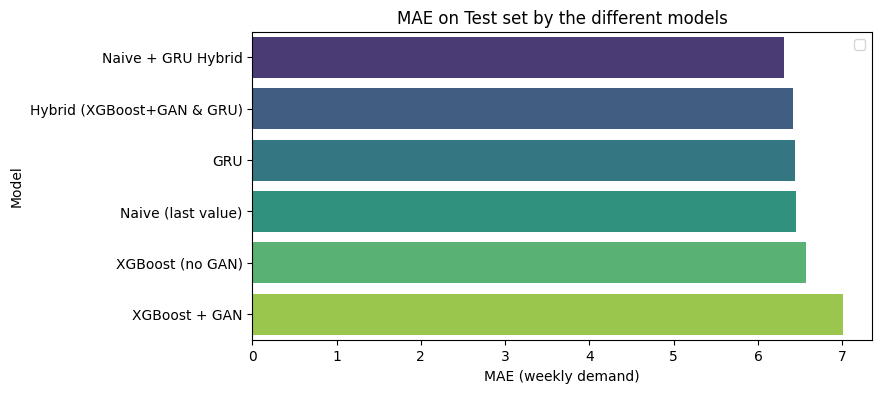

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Test MAE', y='Model', palette='viridis')
# plt.axvline(6.298, color='red', linestyle='--', label="red line shows Olist paper's best reported MAE (naive standalone)")
plt.title('MAE on Test set by the different models')
plt.xlabel('MAE (weekly demand)')
plt.legend()
plt.show()

## A Closer Look: Hybrid Predictions vs Actuals, Selected Categories

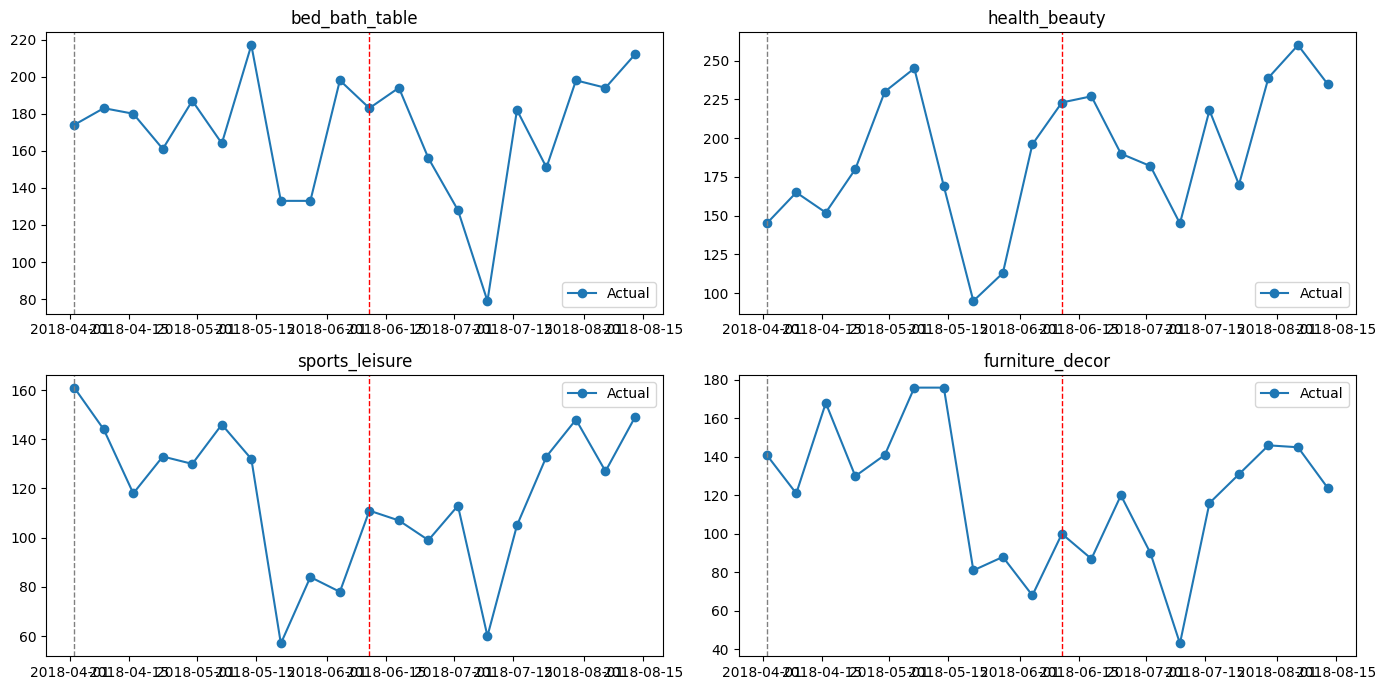

In [ ]:
top_categories = (
    wcp_df.groupby('category')['order_item_volume'].sum().sort_values(ascending=False).head(4).index.tolist()
)

val_test_df = pd.concat([val_df, test_df]).sort_values(['category', 'week']).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)
axes = axes.flatten()

for ax_index in range(4):
    category_name = top_categories[ax_index]
    category_rows = val_test_df[val_test_df['category'] == category_name].sort_values('week')

    ax = axes[ax_index]
    ax.plot(category_rows['week'], category_rows['order_item_volume'], label='Actual', marker='o')
    ax.set_title(category_name)
    ax.axvline(val_weeks[0], color='grey', linestyle='--', linewidth=1)
    ax.axvline(test_weeks[0], color='red', linestyle='--', linewidth=1)
    ax.legend()

plt.tight_layout()
plt.show()

The grey dashed line marks the start of the validation period, and the red dashed line marks the start of the test period.